# SUA preference of unit types in cortical space - NATIM

## Import

In [1]:
import os 
os.chdir('/CSNG/studekat/ripple_paper_clean/code')

In [2]:
from functions_analysis import *
import pandas as pd
import numpy as np
import yaml
import pickle
import neo
import matplotlib.pyplot as plt

## Parameters

In [3]:
with open("/CSNG/studekat/ripple_paper_clean/code/params_analysis.yml") as f:
    params = yaml.safe_load(f)

DATA_FOLDER = params['data_folder']  # folder with all the preprocessed data
DATES = params['dates']

DF_FOLDER = '/CSNG/studekat/ripple_paper_clean/dataframes'  # original version of the dataframes loading 
MONKEY_LIST = ['N','F']
AREAS_MERGED = params['areas_merged']
FINAL_CLASSES = params['final_classes']
COLORS_CLASSES = params['colors_class']

In [4]:
L_coors =np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [5]:
N_coors =np.array([[1,4],[2,3],[2,4],[1,5],  # row, col, the first 4 arrays
           [2,5],[1,6],[2,7],[1,7],
           [1,2],[1,3],[0,4],[0,3],
           [0,2],[1,1],[0,1],[0,0]])

In [6]:
F_coors = np.array([[1,9],[0,9],[1,8],[0,8],  # row, col, the first 4 arrays
           [1,7],[0,7],[1,6],[1,5],
           [0,0],[0,1],[1,1],[0,2],
           [1,2],[0,3],[0,4],[0,5]])

In [7]:
A_coors = np.array([[1,1],[0,0],[0,1],[2,2],  # row, col, the first 4 arrays
           [1,2],[2,3],[1,3],[2,4],
           [1,7],[2,7],[3,7],[1,6],
           [2,6],[1,5],[2,5],[1,4]])

In [8]:
arrays_coors = {'A':A_coors,
              'L':L_coors,
              'N':N_coors,
              'F':F_coors,}
n_rows_dict = {'A':4,
              'L':4,
              'N':3,
              'F':2,}
n_cols_dict = {'A':8,
              'L':8,
              'N':8,
              'F':10,}

## Functions

In [9]:
def aux_units_on_ch(df_sua_all,array,final_classes=FINAL_CLASSES):
    """
    Returns dictionary with unit types on each of the channels.
    So far only for RS recordings.
    """
    df_arr = df_sua_all[df_sua_all['array']==array]
    ch_dict = {k:[] for k in range(64)}
    for ch in range(64):
        df_arr_ch = df_arr[df_arr['channel_order']==ch]
        for cl in final_classes:
            df_cl = df_arr_ch[df_arr_ch['final_class']==cl]
            num_cl_ch = df_cl.shape[0]
            for i in range(num_cl_ch):
                ch_dict[ch].append(cl)
    return ch_dict

In [10]:
def aux_dominant_clique_on_ch(ch_dict):
    """
    Given the distribution of units per channel decides which clique it belongs to.
    """
    clique_dict = {}
    for ch in range(64):
        ch_classes = ch_dict[ch]
        count_orange = sum(v in ['DOWN_wide', 'DOWN_narrow_shallow','DOWN_medium_shallow'] for v in ch_classes)
        count_blue = sum(v in ['UP', 'DOWN_wide','DOWN_narrow_sharp','DOWN_medium_sharp'] for v in ch_classes)
        if count_orange<1 & count_blue<1:
            clique_dict[ch] = 'white'
        elif count_orange>count_blue:
            clique_dict[ch] = 'orange'
        elif count_orange<count_blue:
            clique_dict[ch] = 'blue'
        else:
            clique_dict[ch] = 'gray'
    return clique_dict

## Plotting

In [11]:
color_dict = {'blue':'royalblue',
              'orange':'orangered',
              'gray':'lightgray'}

20220111_B1
20220111_B2
20220111_B3
20220111_B4
20220111_B5
20220111_B6
20220111_B7
20220111_B8
20220111_B9
20220111_B10
20220112_B1
20220112_B2
20220112_B3
20220112_B4
20220112_B5
20220112_B6
20220112_B7
20220112_B8
20220112_B9
20220112_B10
20220112_B11
20220113_B1
20220113_B2
20220113_B3
20220113_B4
20220114_B1
20220114_B2
20220114_B3


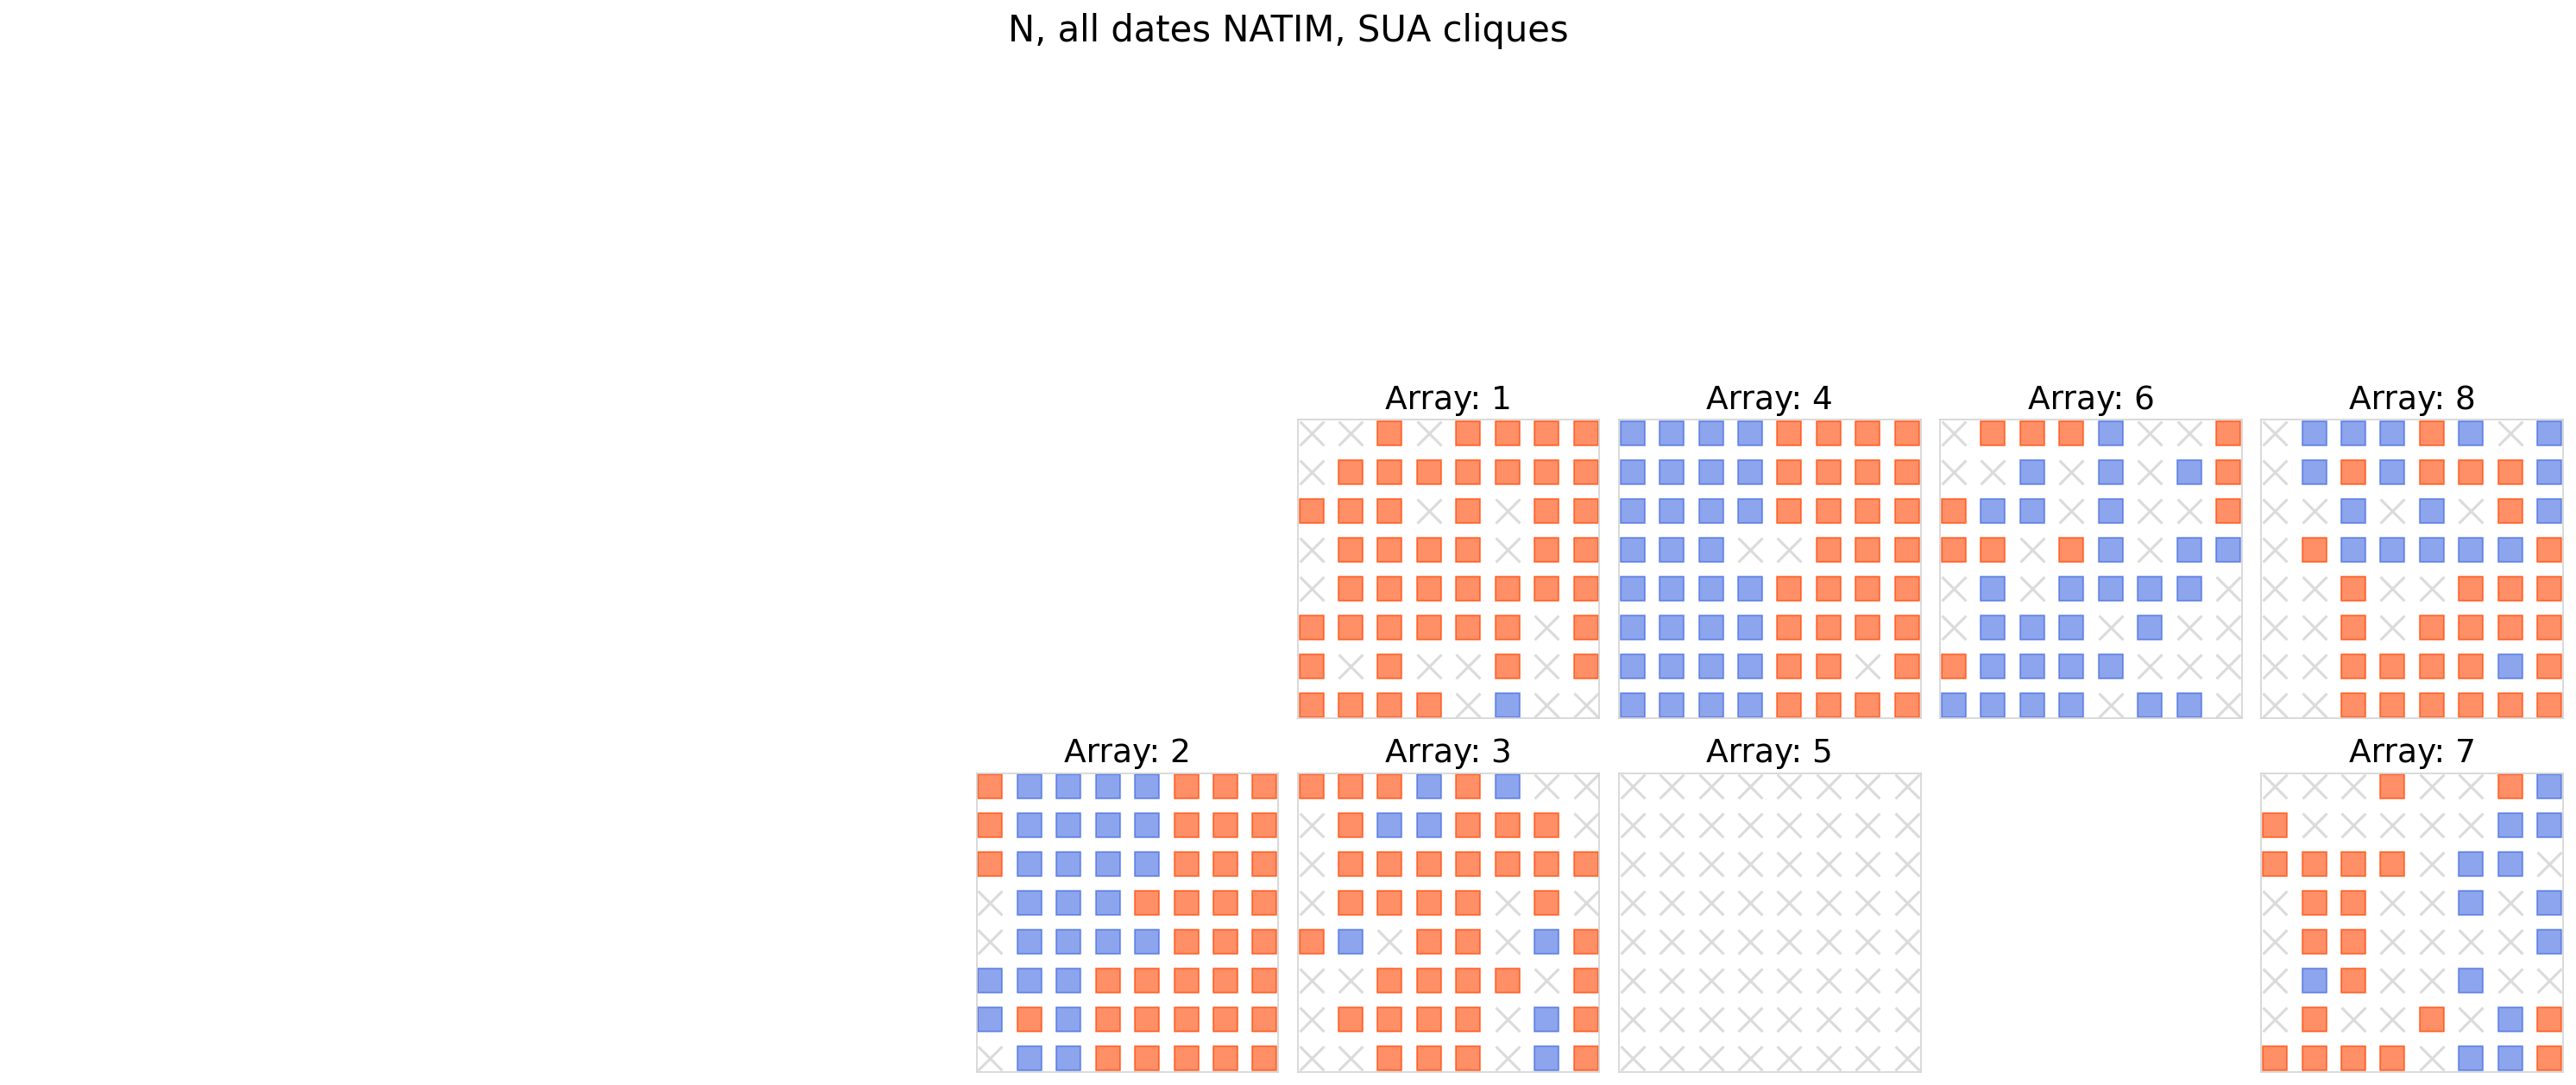

20240112_B1
20240112_B2
20240112_B3
20240112_B4
20240115_B1
20240115_B2
20240115_B3
20240115_B4
20240115_B5
20240116_B1
20240116_B2
20240116_B3
20240116_B4
20240116_B5
20240118_B1
20240118_B2
20240118_B3


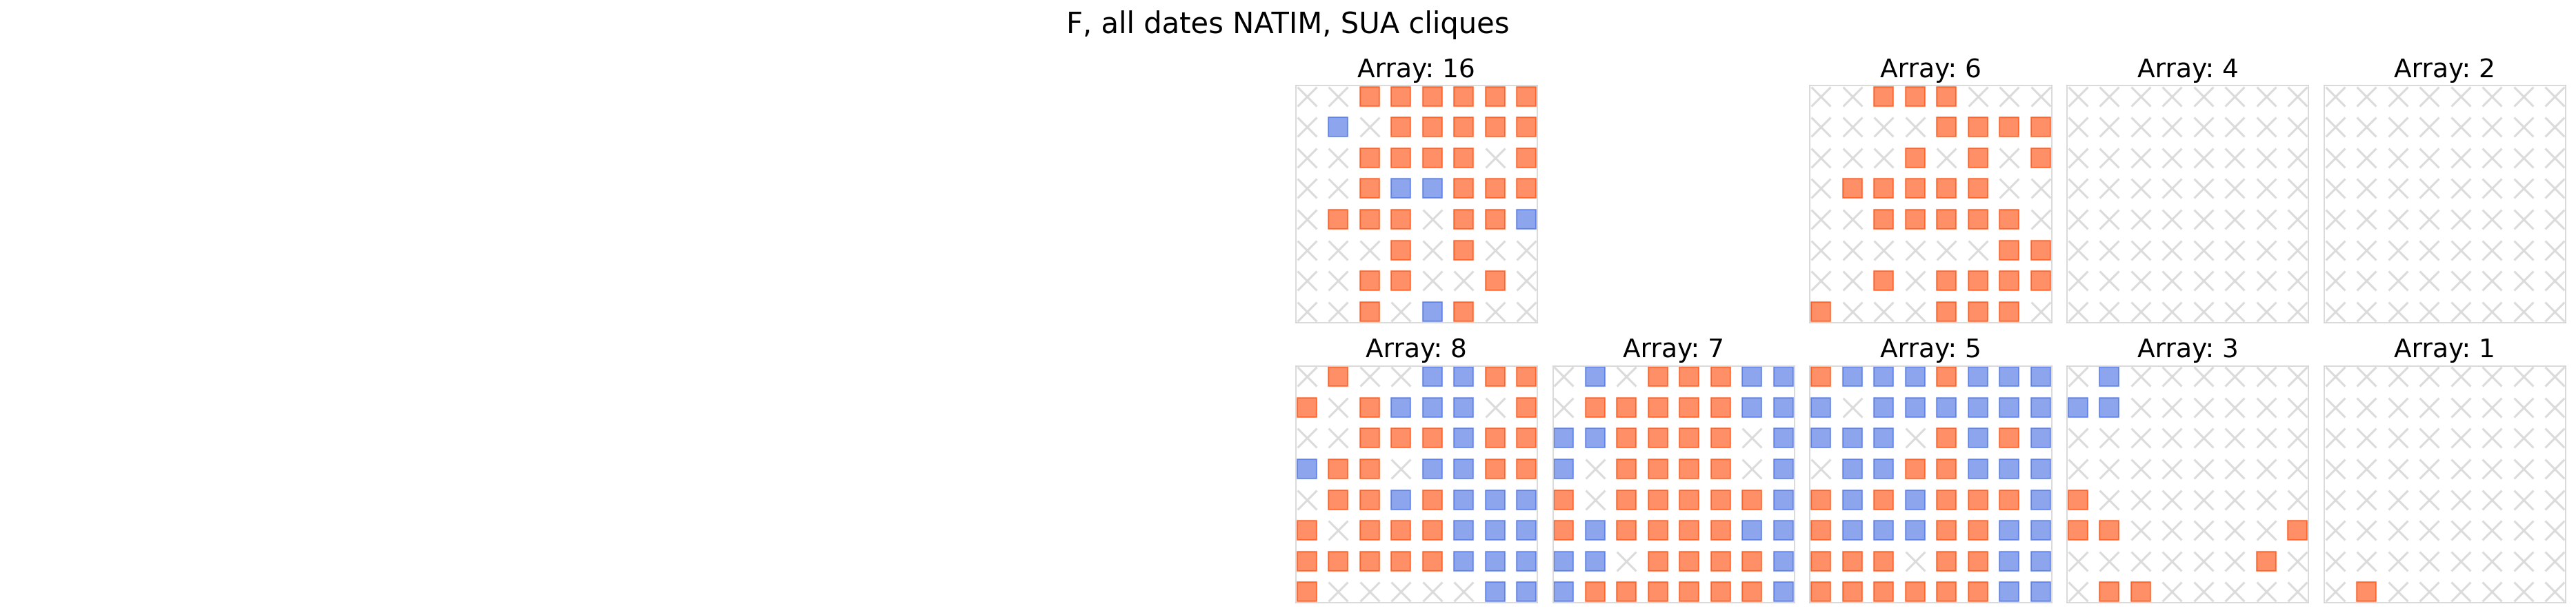

In [12]:
for monkey in ['N','F']:
    monkey_dfs_list = []
    layout_odd = np.array(params['layout'][f'{monkey}_odd'])
    layout_even = np.array(params['layout'][f'{monkey}_even'])
    for date in  params['dates'][monkey]['NATIM']:
        print(date)
        with open(f'{DF_FOLDER}/sua_prop_all_NATIM/monkey{monkey}_all_arrays_date_{date}.pkl', "rb") as file:
            df_prop = pickle.load(file)
            #print(df_prop.shape)
            df_prop = df_prop[~df_prop['ch_is_noisy_120Hz']]
            df_prop = df_prop[~df_prop['ch_is_noisy_100Hz']]
        monkey_dfs_list.append(df_prop)
    df_all = pd.concat(monkey_dfs_list)
    
    n_rows = n_rows_dict[monkey]
    n_cols = n_cols_dict[monkey]
    fig, ax = plt.subplots(n_rows,n_cols,dpi=150)
    fig.set_figwidth(2.5*n_cols)
    fig.set_figheight(2.5*n_rows+1)
    
    plt.suptitle(f'{monkey}, all dates NATIM, SUA cliques',fontsize=20)
    
    for r in range(n_rows):
        for c in range(n_cols):
            ax[r,c].set_xticks([])
            ax[r,c].set_yticks([])
            for spine in ax[r,c].spines.values():
                spine.set_color('white')
    
    for array in range(1,17):
        if array%2==0:
            layout = layout_even
            #print('Even.')
        else:
            layout = layout_odd
            #print('Odd.')

        ch_layout_indices = []
        for ch in range(64):
            layout_idx = np.where(layout==ch)
            layout_idx = np.array([layout_idx[0][0], layout_idx[1][0]]) # reformating from array of arrays to array of two integer coors.
            ch_layout_indices.append(layout_idx)
            
        if params['areas'][monkey][array-1] in ['V1','V2']:
            ch_dict = aux_units_on_ch(df_all,array,final_classes=FINAL_CLASSES)
            clique_dict = aux_dominant_clique_on_ch(ch_dict)
            area = params['areas'][monkey][array-1]
            row_plot = arrays_coors[monkey][array-1][0]
            col_plot = arrays_coors[monkey][array-1][1]
            ax[row_plot,col_plot].set_title(f'Array: {array}',fontsize=18)
            for ch in range(64):
                coor = ch_layout_indices[ch]
                color = clique_dict[ch]
        
                row = coor[1]
                col = coor[0]
                if color in ['orange','blue']:
                    ax[row_plot,col_plot].scatter(row,8-col,c=color_dict[color],alpha=0.6,s=180,marker='s')
                else:
                    ax[row_plot,col_plot].scatter(row,8-col,c=color_dict[color],alpha=0.8,s=180,marker='x')
                for spine in ax[row_plot,col_plot].spines.values():
                    spine.set_color('lightgray')
    
    plt.tight_layout()
    plt.show()
    plt.close()